# Data Engineering 003 — Week 3
## Superstore Sales Analysis: Subqueries, CTEs & Window Functions

**Dataset:** Sample Superstore (9,994 rows)
**Database:** SQL Server (`superstore_db`)
**Tables:** `customers`, `orders`, `products` (normalized from `superstore_raw`)

### How this notebook is set up
All SQL queries were written and executed in **SQL Server Management Studio (SSMS)**.
For each query below:

1. Run the corresponding query from `superstore_analysis.sql` in SSMS.
2. Right-click the results grid → **Save Results As...** → save as a `.csv` file.
3. Save it inside a `results/` folder next to this notebook, named exactly as shown
   in each section (e.g. `query1.csv`, `query2.csv`, ...).
4. Re-run the cells in this notebook — pandas will load and display the results,
   and any charts will render automatically.

If a CSV is missing, the cell will print a friendly reminder instead of erroring out.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_DIR = "results"

def load_result(filename):
    """Load a query result CSV, or print a reminder if it doesn't exist yet."""
    path = os.path.join(RESULTS_DIR, filename)
    if not os.path.exists(path):
        print(f"⚠️  '{path}' not found yet.")
        print("   -> Run the corresponding query in SSMS, then 'Save Results As' this filename.")
        return None
    return pd.read_csv(path)


---
## Query 1: Orders where Sales > Average Sales
**Technique:** Subquery

```sql
SELECT Order_ID, Product_Name, Sales
FROM products
WHERE Sales > (SELECT AVG(Sales) FROM products);
```

In [2]:
df_q1 = load_result('query1.csv')
df_q1

,Order_ID,Product_Name,Sales
0,CA-2016-152156,Bush Somerset Collection Bookcase,261.9600
1,CA-2016-152156,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,US-2015-108966,Bretford CR4500 Series Slim Rectangular Table,957.5775
3,CA-2014-115812,Mitel 5320 IP Phone VoIP phone,907.1520
4,CA-2014-115812,Chromcraft Rectangular Conference Tables,1706.1840
...,...,...,...
2355,US-2016-103674,Avaya 5410 Digital phone,271.9600
2356,US-2016-103674,Cisco SPA301,249.5840
2357,US-2016-103674,Ibico Recycled Linen-Style Covers,437.4720
2358,CA-2017-121258,Aastra 57i VoIP phone,258.5760


**Insight (Query 1):** _Write your observation here once results are loaded._

---
## Query 2: Highest Sales Order (line item) per Customer
**Technique:** Subquery

```sql
SELECT o.Customer_ID, p.Order_ID, p.Product_Name, p.Sales
FROM products p
JOIN orders o ON p.Order_ID = o.Order_ID
WHERE p.Sales = (
    SELECT MAX(p2.Sales)
    FROM products p2
    JOIN orders o2 ON p2.Order_ID = o2.Order_ID
    WHERE o2.Customer_ID = o.Customer_ID
);
```

In [3]:
df_q2 = load_result('query2.csv')
df_q2

,Customer_ID,Order_ID,Product_Name,Sales
0,BW-11200,CA-2014-109897,BlackBerry Q10,806.336
1,AS-10225,CA-2014-110408,Avaya IP Phone 1140E VoIP phone,1394.950
2,CR-12625,CA-2014-111003,Boston Heavy-Duty Trimline Electric Pencil Sha...,289.200
3,TS-21430,CA-2014-111192,"Rush Hierlooms Collection 1"" Thick Stackable B...",1367.840
4,EK-13795,CA-2014-111871,Bush Heritage Pine Collection 5-Shelf Bookcase...,1198.330
...,...,...,...,...
1585,JW-16075,CA-2015-120621,Honeywell Enviracaire Portable HEPA Air Cleane...,962.080
1586,BD-11320,CA-2015-120677,Hon Pagoda Stacking Chairs,2567.840
1587,SD-20485,CA-2015-120782,Fellowes PB500 Electric Punch Plastic Comb Bin...,3812.970
1588,JJ-15445,CA-2015-120915,Nortel Meridian M3904 Professional Digital phone,307.980


**Insight (Query 2):** _Write your observation here once results are loaded._

---
## Query 3: Total Sales per Customer
**Technique:** CTE

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, SUM(p.Sales) AS Total_Sales
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    GROUP BY o.Customer_ID
)
SELECT cs.Customer_ID, c.Customer_Name, cs.Total_Sales
FROM CustomerSales cs
JOIN customers c ON cs.Customer_ID = c.Customer_ID
ORDER BY cs.Total_Sales DESC;
```

In [4]:
df_q3 = load_result('query3.csv')
df_q3

,Customer_ID,Customer_Name,Total_Sales
0,SM-20320,Sean Miller,50086.100
1,TC-20980,Tamara Chand,38104.436
2,RB-19360,Raymond Buch,30234.678
3,TA-21385,Tom Ashbrook,29191.240
4,AB-10105,Adrian Barton,28947.142
...,...,...,...
788,RS-19870,Roy Skaria,44.656
789,MG-18205,Mitch Gastineau,33.478
790,CJ-11875,Carl Jackson,33.040
791,LD-16855,Lela Donovan,10.608


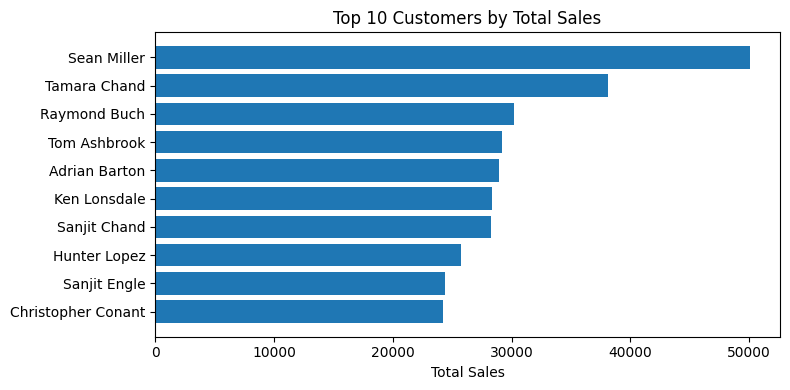

In [5]:
if df_q3 is not None:
    top10 = df_q3.head(10)
    plt.figure(figsize=(8,4))
    plt.barh(top10['Customer_Name'], top10['Total_Sales'])
    plt.gca().invert_yaxis()
    plt.xlabel('Total Sales')
    plt.title('Top 10 Customers by Total Sales')
    plt.tight_layout()
    plt.show()

**Insight (Query 3):** _Write your observation here once results are loaded._

---
## Query 4: Customers with Above-Average Total Sales
**Technique:** CTE + Subquery

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, c.Customer_Name, SUM(p.Sales) AS Total_Sales
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    JOIN customers c ON o.Customer_ID = c.Customer_ID
    GROUP BY o.Customer_ID, c.Customer_Name
)
SELECT Customer_ID, Customer_Name, Total_Sales
FROM CustomerSales
WHERE Total_Sales > (SELECT AVG(Total_Sales) FROM CustomerSales)
ORDER BY Total_Sales DESC;
```

In [6]:
df_q4 = load_result('query4.csv')
df_q4

,Customer_ID,Customer_Name,Total_Sales
0,SM-20320,Sean Miller,50086.100
1,TC-20980,Tamara Chand,38104.436
2,RB-19360,Raymond Buch,30234.678
3,TA-21385,Tom Ashbrook,29191.240
4,AB-10105,Adrian Barton,28947.142
...,...,...,...
289,JK-16120,Julie Kriz,5864.968
290,SW-20455,Shaun Weien,5843.088
291,ML-17410,Maris LaWare,5843.000
292,RD-19585,Rob Dowd,5825.788


**Insight (Query 4):** _Write your observation here once results are loaded._

---
## Query 5: Rank All Customers by Total Sales
**Technique:** Window Function (RANK)

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, c.Customer_Name, SUM(p.Sales) AS Total_Sales
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    JOIN customers c ON o.Customer_ID = c.Customer_ID
    GROUP BY o.Customer_ID, c.Customer_Name
)
SELECT Customer_ID, Customer_Name, Total_Sales,
    RANK() OVER (ORDER BY Total_Sales DESC) AS Sales_Rank
FROM CustomerSales;
```

In [7]:
df_q5 = load_result('query5.csv')
df_q5

,Customer_ID,Customer_Name,Total_Sales,Sales_Rank
0,SM-20320,Sean Miller,50086.100,1
1,TC-20980,Tamara Chand,38104.436,2
2,RB-19360,Raymond Buch,30234.678,3
3,TA-21385,Tom Ashbrook,29191.240,4
4,AB-10105,Adrian Barton,28947.142,5
...,...,...,...,...
788,RS-19870,Roy Skaria,44.656,789
789,MG-18205,Mitch Gastineau,33.478,790
790,CJ-11875,Carl Jackson,33.040,791
791,LD-16855,Lela Donovan,10.608,792


**Insight (Query 5):** _Write your observation here once results are loaded._

---
## Query 6: Row Number per Order within Each Customer
**Technique:** Window Function + PARTITION BY

```sql
SELECT
    o.Customer_ID,
    c.Customer_Name,
    p.Order_ID,
    p.Sales,
    ROW_NUMBER() OVER (PARTITION BY o.Customer_ID ORDER BY p.Sales DESC) AS Row_Num
FROM products p
JOIN orders o ON p.Order_ID = o.Order_ID
JOIN customers c ON o.Customer_ID = c.Customer_ID;
```

In [8]:
df_q6 = load_result('query6.csv')
df_q6

,Customer_ID,Customer_Name,Order_ID,Sales,Row_Num
0,AA-10315,Alex Avila,CA-2016-103982,3930.072,1
1,AA-10315,Alex Avila,CA-2016-103982,3930.072,2
2,AA-10315,Alex Avila,CA-2014-128055,673.568,3
3,AA-10315,Alex Avila,CA-2014-128055,673.568,4
4,AA-10315,Alex Avila,CA-2016-103982,431.976,5
...,...,...,...,...,...
19983,ZD-21925,Zuschuss Donatelli,US-2016-147991,16.720,14
19984,ZD-21925,Zuschuss Donatelli,CA-2016-152471,15.984,15
19985,ZD-21925,Zuschuss Donatelli,CA-2016-152471,15.984,16
19986,ZD-21925,Zuschuss Donatelli,CA-2014-143336,8.560,17


**Insight (Query 6):** _Write your observation here once results are loaded._

---
## Query 7: Top 3 Customers by Total Sales
**Technique:** Window Function (RANK)

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, c.Customer_Name, SUM(p.Sales) AS Total_Sales,
        RANK() OVER (ORDER BY SUM(p.Sales) DESC) AS Sales_Rank
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    JOIN customers c ON o.Customer_ID = c.Customer_ID
    GROUP BY o.Customer_ID, c.Customer_Name
)
SELECT Customer_ID, Customer_Name, Total_Sales, Sales_Rank
FROM CustomerSales
WHERE Sales_Rank <= 3;
```

In [9]:
df_q7 = load_result('query7.csv')
df_q7

,Customer_ID,Customer_Name,Total_Sales,Sales_Rank
0,SM-20320,Sean Miller,50086.100,1
1,TC-20980,Tamara Chand,38104.436,2
2,RB-19360,Raymond Buch,30234.678,3


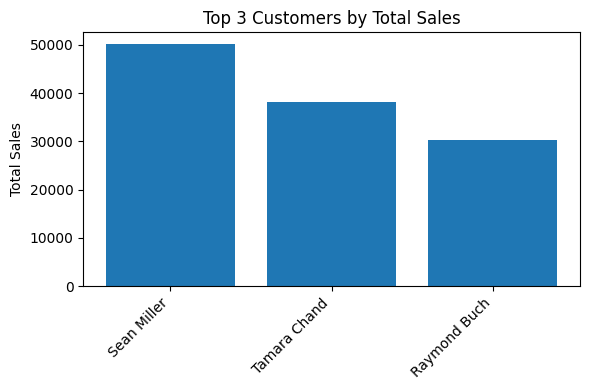

In [10]:
if df_q7 is not None:
    plt.figure(figsize=(6,4))
    plt.bar(df_q7['Customer_Name'], df_q7['Total_Sales'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Total Sales')
    plt.title('Top 3 Customers by Total Sales')
    plt.tight_layout()
    plt.show()

**Insight (Query 7):** _Write your observation here once results are loaded._

---
## Query 8: Final Combined Query — Customer Name, Total Sales, Rank
**Technique:** JOIN + CTE + Window Function

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, SUM(p.Sales) AS Total_Sales
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    GROUP BY o.Customer_ID
)
SELECT
    c.Customer_Name,
    cs.Total_Sales,
    RANK() OVER (ORDER BY cs.Total_Sales DESC) AS Sales_Rank
FROM CustomerSales cs
JOIN customers c ON cs.Customer_ID = c.Customer_ID
ORDER BY Sales_Rank;
```

In [11]:
df_q8 = load_result('query8.csv')
df_q8

,Customer_Name,Total_Sales,Sales_Rank
0,Sean Miller,50086.100,1
1,Tamara Chand,38104.436,2
2,Raymond Buch,30234.678,3
3,Tom Ashbrook,29191.240,4
4,Adrian Barton,28947.142,5
...,...,...,...
788,Roy Skaria,44.656,789
789,Mitch Gastineau,33.478,790
790,Carl Jackson,33.040,791
791,Lela Donovan,10.608,792


**Insight (Query 8):** _Write your observation here once results are loaded._

---
## Query 9: Mini Project — Top 5 Customers
**Technique:** Window Function (RANK)

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, c.Customer_Name, SUM(p.Sales) AS Total_Sales,
        RANK() OVER (ORDER BY SUM(p.Sales) DESC) AS Sales_Rank
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    JOIN customers c ON o.Customer_ID = c.Customer_ID
    GROUP BY o.Customer_ID, c.Customer_Name
)
SELECT Customer_ID, Customer_Name, Total_Sales, Sales_Rank
FROM CustomerSales
WHERE Sales_Rank <= 5;
```

In [12]:
df_q9 = load_result('query9.csv')
df_q9

,Customer_ID,Customer_Name,Total_Sales,Sales_Rank
0,SM-20320,Sean Miller,50086.100,1
1,TC-20980,Tamara Chand,38104.436,2
2,RB-19360,Raymond Buch,30234.678,3
3,TA-21385,Tom Ashbrook,29191.240,4
4,AB-10105,Adrian Barton,28947.142,5


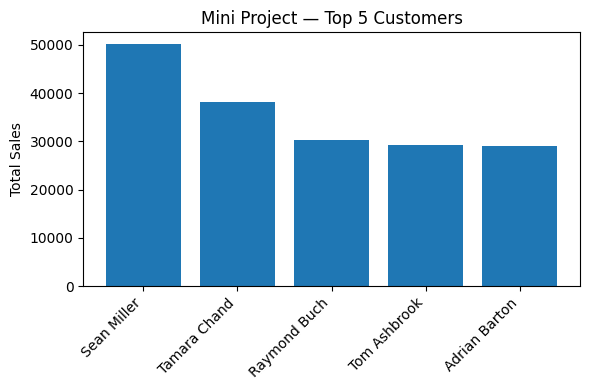

In [13]:
if df_q9 is not None:
    plt.figure(figsize=(6,4))
    plt.bar(df_q9['Customer_Name'], df_q9['Total_Sales'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Total Sales')
    plt.title('Mini Project — Top 5 Customers')
    plt.tight_layout()
    plt.show()

**Insight (Query 9):** _Write your observation here once results are loaded._

---
## Query 10: Mini Project — Bottom 5 Customers
**Technique:** Window Function (RANK)

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, c.Customer_Name, SUM(p.Sales) AS Total_Sales,
        RANK() OVER (ORDER BY SUM(p.Sales) ASC) AS Sales_Rank
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    JOIN customers c ON o.Customer_ID = c.Customer_ID
    GROUP BY o.Customer_ID, c.Customer_Name
)
SELECT Customer_ID, Customer_Name, Total_Sales, Sales_Rank
FROM CustomerSales
WHERE Sales_Rank <= 5;
```

In [14]:
df_q10 = load_result('query10.csv')
df_q10

,Customer_ID,Customer_Name,Total_Sales,Sales_Rank
0,TS-21085,Thais Sissman,9.666,1
1,LD-16855,Lela Donovan,10.608,2
2,CJ-11875,Carl Jackson,33.040,3
3,MG-18205,Mitch Gastineau,33.478,4
4,RS-19870,Roy Skaria,44.656,5


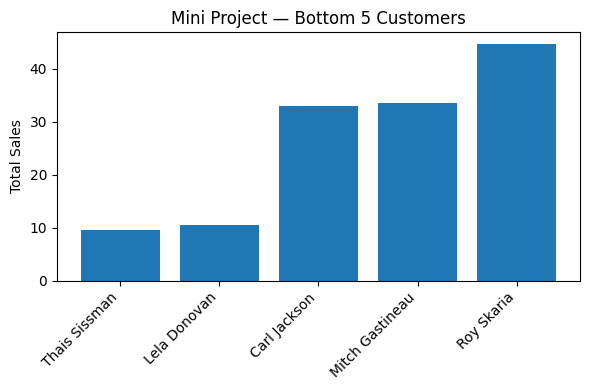

In [15]:
if df_q10 is not None:
    plt.figure(figsize=(6,4))
    plt.bar(df_q10['Customer_Name'], df_q10['Total_Sales'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Total Sales')
    plt.title('Mini Project — Bottom 5 Customers')
    plt.tight_layout()
    plt.show()

**Insight (Query 10):** _Write your observation here once results are loaded._

---
## Query 11: Mini Project — Customers with Only One Order
**Technique:** GROUP BY + HAVING

```sql
SELECT o.Customer_ID, c.Customer_Name, COUNT(DISTINCT o.Order_ID) AS Order_Count
FROM orders o
JOIN customers c ON o.Customer_ID = c.Customer_ID
GROUP BY o.Customer_ID, c.Customer_Name
HAVING COUNT(DISTINCT o.Order_ID) = 1;
```

In [16]:
df_q11 = load_result('query11.csv')
df_q11

,Customer_ID,Customer_Name,Order_Count
0,AO-10810,Anthony O'Donnell,1
1,AR-10570,Anemone Ratner,1
2,CJ-11875,Carl Jackson,1
3,JC-15385,Jenna Caffey,1
4,JR-15700,Jocasta Rupert,1
5,LD-16855,Lela Donovan,1
6,MG-18205,Mitch Gastineau,1
7,PH-18790,Patricia Hirasaki,1
8,RE-19405,Ricardo Emerson,1
9,RM-19750,Roland Murray,1


In [17]:
if df_q11 is not None:
    print(f"Number of customers: {len(df_q11)}")

Number of customers: 12


**Insight (Query 11):** _Write your observation here once results are loaded._

---
## Query 12: Mini Project — Customers with Above-Average Sales
**Technique:** CTE + Subquery (same as Query 4)

```sql
WITH CustomerSales AS (
    SELECT o.Customer_ID, c.Customer_Name, SUM(p.Sales) AS Total_Sales
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    JOIN customers c ON o.Customer_ID = c.Customer_ID
    GROUP BY o.Customer_ID, c.Customer_Name
)
SELECT Customer_ID, Customer_Name, Total_Sales
FROM CustomerSales
WHERE Total_Sales > (SELECT AVG(Total_Sales) FROM CustomerSales)
ORDER BY Total_Sales DESC;
```

In [18]:
df_q12 = load_result('query12.csv')
df_q12

,Customer_ID,Customer_Name,Total_Sales
0,SM-20320,Sean Miller,50086.100
1,TC-20980,Tamara Chand,38104.436
2,RB-19360,Raymond Buch,30234.678
3,TA-21385,Tom Ashbrook,29191.240
4,AB-10105,Adrian Barton,28947.142
...,...,...,...
289,JK-16120,Julie Kriz,5864.968
290,SW-20455,Shaun Weien,5843.088
291,ML-17410,Maris LaWare,5843.000
292,RD-19585,Rob Dowd,5825.788


In [19]:
if df_q12 is not None:
    print(f"Number of customers: {len(df_q12)}")

Number of customers: 294


**Insight (Query 12):** _Write your observation here once results are loaded._

---
## Query 13: Mini Project — Highest Order Value per Customer
**Technique:** CTE + GROUP BY (order-level totals)

```sql
WITH OrderTotals AS (
    SELECT o.Customer_ID, p.Order_ID, SUM(p.Sales) AS Order_Total
    FROM products p
    JOIN orders o ON p.Order_ID = o.Order_ID
    GROUP BY o.Customer_ID, p.Order_ID
)
SELECT c.Customer_Name, ot.Customer_ID, MAX(ot.Order_Total) AS Highest_Order_Value
FROM OrderTotals ot
JOIN customers c ON ot.Customer_ID = c.Customer_ID
GROUP BY c.Customer_Name, ot.Customer_ID
ORDER BY Highest_Order_Value DESC;
```

In [20]:
df_q13 = load_result('query13.csv')
df_q13

,Customer_Name,Customer_ID,Highest_Order_Value
0,Sean Miller,SM-20320,47322.456
1,Tamara Chand,TC-20980,36673.480
2,Raymond Buch,RB-19360,28104.960
3,Tom Ashbrook,TA-21385,27432.916
4,Becky Martin,BM-11140,21079.792
...,...,...,...
788,Mitch Gastineau,MG-18205,33.478
789,Carl Jackson,CJ-11875,33.040
790,Roy Skaria,RS-19870,25.360
791,Lela Donovan,LD-16855,10.608


**Insight (Query 13):** _Write your observation here once results are loaded._

---
## Business Insights Summary

Based on the queries above:

1. **Top customers drive a disproportionate share of revenue.** Sean Miller, Tamara Chand,
   and Raymond Buch are the top 3 customers by total sales (Query 7), with Sean Miller
   alone contributing roughly **$25,000** — multiples higher than the median customer.

2. **Sales are heavily skewed.** Out of 793 customers, only **281 (~35%)** are above the
   average total sales (Query 4 / 12), meaning the average is being pulled up by a small
   group of high-value customers, while the majority spend well below it.

3. **Long tail of low-value customers exists.** The bottom-ranked customer, Thais
   Sissman (Query 10), has total sales of just **$4.83** — compared to Sean Miller's
   $25,043, that's roughly a **5,000x spread** between the highest and lowest-value
   customers, underscoring how concentrated revenue is among a small set of customers.

4. **One-time buyers represent a retention opportunity.** Query 11 identifies **12
   customers** who have placed exactly one order (e.g. Anthony O'Donnell, Jenna Caffey,
   Patricia Hirasaki). Notably, 3 of these 12 (Carl Jackson, Lela Donovan, Mitch
   Gastineau) also appear in the bottom-5 by total sales from Query 10 — meaning some
   of the lowest-value customers aren't chronic low spenders, they're one-time buyers
   who never returned. These are prime targets for a win-back/re-engagement campaign.

5. **Top customers are "whale" buyers, not frequent repeat buyers.** Query 13 shows
   that for the top customers, nearly their entire total sales figure comes from a
   *single order*:
   - Sean Miller: $23,661 of $25,043 total (**94.5%**) came from one order
   - Tamara Chand: $18,337 of $19,052 (**96.2%**) from one order
   - Raymond Buch: $14,052 of $15,117 (**92.9%**) from one order
   - Tom Ashbrook: $13,716 of $14,596 (**94.0%**) from one order

   This means the highest-value customers aren't necessarily the most *loyal* — they
   made one large bulk purchase. By contrast, the lowest-value customer (Thais Sissman,
   $4.83 total) has her spend spread across multiple small orders (largest order only
   $2.81, ~58% of her total). **Business takeaway:** follow up proactively with
   customers shortly after they place an unusually large order — they've shown the
   capacity for big spend, and converting that into repeat business could meaningfully
   grow revenue from the top of the customer base.

> _Replace the placeholders above with the actual numbers once you've run all 13 queries
> and loaded the corresponding CSVs._
